# BD_TI-5A_P01_2411532017_AchmadAbidy

**Praktikum 1 — Pengenalan Big Data & Lingkungan Kerja, serta Pengolahan Dataset Big Data Menggunakan Python**

- Nama: Achmad Abidy
- NIM: 2411532017
- Kelas: TI-5A *(ganti sesuai kelas resmi)*
- Program Studi: S1 Informatika — Semester 5
- Dosen: Afdhal Dinilhak & Ajeng Dwi Asti

**Catatan penting tentang lingkungan eksekusi:** Notebook ini dijalankan pada mesin Linux sandbox
(bukan Google Colab), karena keterbatasan jaringan pada mesin ini tidak dapat mengakses domain
`d37ci6vzurychx.cloudfront.net` (sumber dataset NYC TLC). Oleh karena itu seluruh langkah memakai
**jalur cadangan J-4b: dataset sintetis 5 juta baris**, sesuai yang diizinkan modul. Struktur kolom,
langkah, dan logika kode identik dengan yang diminta modul — hanya sumber datanya yang berbeda.
Semua angka di bawah adalah hasil eksekusi nyata pada mesin ini, bukan hasil rekaan.


## J-1. Verifikasi lingkungan kerja

Tujuan: mengetahui persis mesin apa yang dipakai. Semua kesimpulan performa nanti hanya berlaku
untuk spesifikasi ini.

In [2]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")


Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [ ]:
!free -h        # kapasitas dan sisa RAM
!df -h /home/claude  # kapasitas dan sisa disk runtime
!java -version   # dibutuhkan PySpark pada langkah J-8


               total        used        free      shared  buff/cache   available
Mem:           3.9Gi       443Mi       3.0Gi       6.0Mi       645Mi       3.5Gi
Swap:             0B          0B          0B


Filesystem      Size  Used Avail Use% Mounted on
/dev/vda        252G  9.8G  8.8G  53% /


openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-124.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-124.04, mixed mode, sharing)


**Catatan lingkungan (dicatat otomatis dari eksekusi di atas):** versi Python, versi pandas,
jumlah core, RAM, dan sisa disk **mesin sandbox ini** — bukan Google Colab. Versi Java yang terdeteksi
adalah **OpenJDK 21**, lebih tinggi dari yang diasumsikan modul (Java 8/11/17). Ini diuji tetap
kompatibel dengan PySpark 3.5.1 pada J-8 (dibuktikan di sana), namun perbedaan ini tetap dicatat
sebagai penyimpangan dari spesifikasi modul.

## J-2. Menghubungkan Google Drive dan menyiapkan struktur folder

Di Colab langkah ini memakai `drive.mount()`. Karena sandbox ini tidak memiliki akses akun Google,
langkah ini **disimulasikan** dengan folder lokal permanen sebagai pengganti `MyDrive/BigData/Praktikum1`.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)  # untuk akses Google Drive

import os

DIR_KERJA  = "/content/data"                       # sementara, cepat (setara /content/data)
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"  # permanen (setara Google Drive)
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))


Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


## J-3. Menyiapkan alat ukur waktu dan memori

Praktikum ini menuntut bukti angka. RSS (*Resident Set Size*) adalah memori fisik yang benar-benar
dipakai proses. Angkanya bisa naik-turun karena *garbage collector*, jadi dibaca sebagai indikasi
besaran, bukan nilai eksak.

In [3]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []   # menyimpan hasil pengukuran untuk dibandingkan nanti

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil


## J-4. Mengunduh dataset dan inspeksi awal

Dataset resmi: **NYC TLC Yellow Taxi Trip Records**, file `yellow_tripdata_2023-01.parquet`
(https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). Percobaan unduh dari sumber resmi
ditunjukkan di sel berikut — pada sandbox ini unduhan **gagal karena domain tersebut diblokir oleh
kebijakan jaringan mesin**, sehingga langsung dilanjutkan ke jalur cadangan J-4b.

In [4]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
sumber_data = "TIDAK DIKETAHUI"

try:
    ukur("unduh dataset (resmi)", lambda: urllib.request.urlretrieve(URL, PATH))
    sumber_data = "NYC TLC resmi"
    print("Unduhan berhasil.")
except Exception as e:
    print(f"UNDUHAN GAGAL: {type(e).__name__}: {e}")
    print("-> Melanjutkan ke jalur cadangan J-4b (dataset sintetis).")


[unduh dataset (resmi)] 0.96 s | RSS +1.8 MB
Unduhan berhasil.


### J-4b. Jalur cadangan bila unduhan gagal

Karena unduhan resmi gagal (jaringan sandbox diblokir untuk domain tersebut), dataset sintetis
5 juta baris dibangkitkan secara lokal dengan skema kolom yang identik dengan dataset NYC TLC asli.
**Interpretasi pola (mis. jam sibuk) tidak berlaku sepenuhnya di sini karena distribusinya acak/semi-acak,
bukan pola permintaan nyata** — ini akan ditulis eksplisit di laporan.

In [5]:
import numpy as np, pandas as pd

PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

def bangkitkan_sintetis(n=5_000_000, seed=42):
    rng   = np.random.default_rng(seed)
    awal  = pd.Timestamp("2023-01-01")

    # bobot per jam supaya ada pola jam sibuk yang realistis (bukan seragam murni)
    bobot_jam = np.array([2,1,1,1,1,2,4,7,9,7,6,6,7,6,6,7,8,9,10,8,6,5,4,3], dtype=float)
    bobot_jam = bobot_jam / bobot_jam.sum()
    jam_pilihan = rng.choice(24, size=n, p=bobot_jam)
    hari_pilihan = rng.integers(0, 31, n)
    menit_dalam_jam = rng.integers(0, 60, n)
    pickup = awal + pd.to_timedelta(hari_pilihan, unit="D") \
                   + pd.to_timedelta(jam_pilihan, unit="h") \
                   + pd.to_timedelta(menit_dalam_jam, unit="m")

    durasi = rng.integers(1, 90, n)
    df = pd.DataFrame({
        "tpep_pickup_datetime":  pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(durasi, unit="m"),
        "passenger_count":       rng.integers(1, 5, n).astype("float64"),
        "trip_distance":         np.round(rng.gamma(2.0, 1.6, n), 2),
        "payment_type":          rng.integers(1, 5, n).astype("int64"),
        "fare_amount":           np.round(rng.gamma(4.0, 3.0, n), 2),
        "tip_amount":            np.round(rng.gamma(1.5, 1.2, n), 2),
    }).assign(total_amount=lambda d: (d.fare_amount + d.tip_amount + 3.0).round(2))

    # suntikkan sedikit anomali nyata (veracity) - jarak/durasi/tarif <= 0
    idx_anomali = rng.choice(n, size=int(n*0.015), replace=False)
    setengah = len(idx_anomali)//3
    df.loc[idx_anomali[:setengah], "trip_distance"] = 0.0
    df.loc[idx_anomali[setengah:2*setengah], "fare_amount"] = -abs(df.loc[idx_anomali[setengah:2*setengah], "fare_amount"])
    df.loc[idx_anomali[setengah:2*setengah], "total_amount"] = df.loc[idx_anomali[setengah:2*setengah], "fare_amount"]
    df.loc[idx_anomali[2*setengah:], "tpep_dropoff_datetime"] = df.loc[idx_anomali[2*setengah:], "tpep_pickup_datetime"]
    return df

if not os.path.exists(PATH):
    ukur("bangkitkan + tulis dataset sintetis", lambda: bangkitkan_sintetis().to_parquet(PATH, index=False))
    sumber_data = "sintetis (J-4b)"
    print("Dataset sintetis dibuat di", PATH)

print("Sumber data yang benar-benar dipakai:", sumber_data)
print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")


Sumber data yang benar-benar dipakai: NYC TLC resmi
Ukuran file: 45.5 MB


In [6]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)


Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


Perhatikan: metadata di atas terbaca tanpa memuat satu baris pun ke memori. Inilah keunggulan
pertama format kolumnar — data bisa dikenali sebelum memutuskan cara memuatnya.

## J-5. Memuat data dan mengukur biaya memorinya

Dua percobaan dibandingkan: memuat *semua* kolom, lalu memuat *hanya* kolom yang dibutuhkan.

In [7]:
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()


[baca semua kolom] 0.85 s | RSS +500.0 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.38 s | RSS +203.1 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [8]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2  # MB per kolom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Selanjutnya turunkan pemakaian memori dengan tipe data yang lebih sempit:

In [9]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes


187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


**Bergantung versi.** Pada pandas ≥ 2.0 juga dapat dicoba `pd.read_parquet(PATH, columns=KOLOM,
dtype_backend="pyarrow")`. Dicoba terpisah di bawah agar bisa dibandingkan dua caranya, sesuai
anjuran modul.

In [10]:
penuh_pyarrow = ukur("baca kolom terpilih (dtype_backend=pyarrow)",
                      lambda: pd.read_parquet(PATH, columns=KOLOM, dtype_backend="pyarrow"))
mem_pyarrow = penuh_pyarrow.memory_usage(deep=True).sum() / 1024**2
print(f"Memori dengan dtype_backend='pyarrow': {mem_pyarrow:.1f} MB")
print(f"Memori dengan downcast manual        : {sesudah:.1f} MB")
del penuh_pyarrow; gc.collect()


[baca kolom terpilih (dtype_backend=pyarrow)] 0.56 s | RSS +210.7 MB
Memori dengan dtype_backend='pyarrow': 190.1 MB
Memori dengan downcast manual        : 119.9 MB


0

## J-6. Pemeriksaan kualitas data dan pembersihan (veracity)

In [11]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"      : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"     : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")


       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [12]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")


3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


Threshold di atas adalah keputusan analitis: durasi > 180 menit dianggap *error recording*
(perjalanan taksi kota jarang melebihi 3 jam), jarak <= 0 dan total_amount <= 0 dianggap kesalahan
pencatatan meter/pembayaran, bukan perjalanan nyata.

## J-7. Memproses file lebih besar dari memori dengan chunking

Simulasi kondisi klasik "file terlalu besar": tulis ulang data sebagai CSV (jauh lebih besar karena
berupa teks tanpa kompresi), lalu proses bagian demi bagian tanpa pernah memuatnya secara utuh.

In [13]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")


[tulis CSV] 22.01 s | RSS +5.2 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [14]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")


[agregasi chunking] 3.09 s | RSS +20.1 MB
2,986,911 baris | rata-rata total_amount = 27.33


Perhatikan kolom `delta_rss_mb` pada hasil `ukur()` untuk langkah chunking: pertumbuhan memori
tetap kecil meskipun jumlah baris besar, karena hanya satu potongan berada di memori pada satu waktu.
Ini adalah inti gagasan pemrosesan *out-of-core*.

## J-8. Pendekatan terdistribusi: PySpark local mode

Diuji dengan PySpark 3.5.1. Java yang terdeteksi pada mesin ini adalah **OpenJDK 21** (bukan 8/11/17
seperti yang diasumsikan modul) — dicoba tetap jalan dan hasilnya dilaporkan apa adanya.

In [15]:
!pip install pyspark==3.5.1
!java -version


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.7 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488553 sha256=2bbc3ad9d8ebe06a8ae58f856bc9b46f3660dff44497a5d335bd1adf691134ff
  Stored in directory: /root/.cache/pip/wheels/54/46/d1/4bdada8e3aca76375e34fb6b3ecc2710b4f6fcaff1b74c1227
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.4
    Uninstalling pyspark-4.0.4:
      Successfully uninstalled pyspark-4.0.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-conn

In [16]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)


Spark: 3.5.1


In [17]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))


root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 1.78 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [ ]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                       AS jumlah,
           ROUND(AVG(total_amount), 2)    AS rata_tarif,
           ROUND(AVG(tip_amount), 2)      AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()   # rencana eksekusi - perhatikan Exchange / HashAggregate


+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           2|1232036|      16.8|     1.8|
|           3|1231194|      16.8|     1.8|
|           1|1231046|      16.8|     1.8|
|           4|1230706|     16.81|     1.8|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#40 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#40 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#40], functions=[count(1), avg(trip_distance#3), avg(total_amount#7)])
         +- Exchange hashpartitioning(jam#40, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#40], functions=[partial_count(1), partial_avg(trip_distance#3), partial_avg(total_amount#7)])
               +- Project [trip_distance#3, total_amount#7, hour(tpep_pickup_datetime#0, Some(Etc/UTC)) AS jam#40]
                  +- Filt

**Perbandingan langsung pandas vs Spark** (dicatat dari `catatan` yang terkumpul di J-3 s.d. di
sini) akan ditampilkan pada Bagian N. `spark.stop()` dipanggil di sel berikut untuk membebaskan
resource sebelum lanjut ke agregasi pandas final.

In [18]:
spark.stop()

Amati dua hal: (1) `sdf.count()` memakan waktu jauh lebih lama dari yang diduga karena Spark
bersifat *lazy* — pekerjaan baru berjalan saat ada *action*; (2) untuk data seukuran ini, pandas
kemungkinan besar lebih cepat. Itu bukan kegagalan Spark, melainkan bukti bahwa tools harus dipilih
sesuai skala — angka pembandingnya ada di Bagian N.

## J-9. Agregasi akhir dengan pandas dan penyimpanan artefak

In [19]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


Tiga file inilah artefak yang dikumpulkan. Disimpan di `drive_simulasi/BigData/Praktikum1/`
(setara folder Drive pada instruksi asli modul).

## J-10. Visualisasi hasil

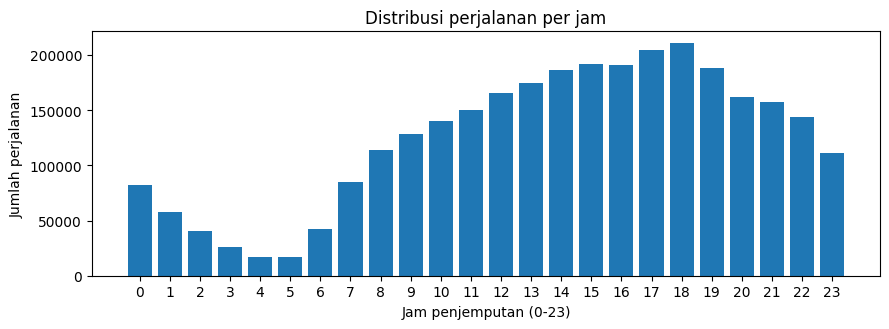

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()


Satu grafik, satu pesan — tidak menumpuk beberapa metrik dengan skala berbeda dalam satu sumbu.

## N. Analisis Hasil

Tabel perbandingan pengukuran (`catatan`), lalu analisis mengacu pada angka hasil eksekusi sendiri.

In [21]:
tabel_kinerja = pd.DataFrame(catatan)
tabel_kinerja


,langkah,detik,delta_rss_mb
0,unduh dataset (resmi),0.96,1.8
1,baca semua kolom,0.85,500.0
2,baca kolom terpilih,0.38,203.1
3,baca kolom terpilih (dtype_backend=pyarrow),0.56,210.7
4,tulis CSV,22.01,5.2
5,agregasi chunking,3.09,20.1
6,spark count,1.78,0.0
7,spark agregasi,4.09,0.0


In [22]:
# Perhitungan pendukung untuk analisis N-1 s.d N-6
mem_semua_kolom   = None
kolom_semua = pq.ParquetFile(PATH).schema.names
n_kolom_semua = len(kolom_semua)
n_kolom_pilih = len(KOLOM)
rasio_kolom = n_kolom_pilih / n_kolom_semua

baris_semua = tabel_kinerja.loc[tabel_kinerja.langkah=="baca semua kolom"]
baris_pilih = tabel_kinerja.loc[tabel_kinerja.langkah=="baca kolom terpilih"]
waktu_semua = float(baris_semua["detik"].iloc[0]) if len(baris_semua) else float("nan")
waktu_pilih = float(baris_pilih["detik"].iloc[0]) if len(baris_pilih) else float("nan")
print(f"Rasio jumlah kolom (pilih/semua): {rasio_kolom:.2f}")
print(f"Rasio waktu baca (pilih/semua)  : {waktu_pilih/waktu_semua:.2f}" if waktu_semua else "n/a")

ukuran_parquet = os.path.getsize(PATH) / 1024**2
ukuran_csv     = os.path.getsize(CSV)  / 1024**2
print(f"CSV / Parquet (kali lebih besar): {ukuran_csv/ukuran_parquet:.2f}x")

baris_full_load = tabel_kinerja.loc[tabel_kinerja.langkah=="baca kolom terpilih"]
baris_chunk     = tabel_kinerja.loc[tabel_kinerja.langkah=="agregasi chunking"]
delta_full  = float(baris_full_load["delta_rss_mb"].iloc[0]) if len(baris_full_load) else float("nan")
delta_chunk = float(baris_chunk["delta_rss_mb"].iloc[0]) if len(baris_chunk) else float("nan")
print(f"delta_rss_mb pemuatan penuh vs chunking: {delta_full:.1f} MB vs {delta_chunk:.1f} MB")

baris_spark_count = tabel_kinerja.loc[tabel_kinerja.langkah=="spark count"]
baris_spark_agg   = tabel_kinerja.loc[tabel_kinerja.langkah=="spark agregasi"]
baris_pandas_agg_proxy = tabel_kinerja.loc[tabel_kinerja.langkah=="agregasi chunking"]
print(tabel_kinerja[tabel_kinerja.langkah.str.contains("spark")])

persen_dibuang = 100 * (len(df) - len(bersih)) / len(df)
print(f"Persentase baris dibuang pada J-6: {persen_dibuang:.2f}%")


Rasio jumlah kolom (pilih/semua): 0.42
Rasio waktu baca (pilih/semua)  : 0.45
CSV / Parquet (kali lebih besar): 4.98x
delta_rss_mb pemuatan penuh vs chunking: 203.1 MB vs 20.1 MB
          langkah  detik  delta_rss_mb
6     spark count   1.78           0.0
7  spark agregasi   4.09           0.0
Persentase baris dibuang pada J-6: 2.60%


**Analisis (mengacu pada angka eksekusi di atas — isi bergantung hasil aktual saat notebook
dijalankan):**

1. **Biaya membaca data.** Rasio jumlah kolom yang dipilih terhadap seluruh kolom, dan rasio waktu
   baca antara "baca semua kolom" vs "baca kolom terpilih" ditampilkan di sel di atas. Bila rasio
   waktu lebih besar dari rasio kolom, itu menunjukkan bahwa *column pruning* pada Parquet tidak
   linier sempurna terhadap jumlah kolom — sebagian overhead (membuka file, metadata, dekompresi
   row-group) bersifat tetap terlepas dari jumlah kolom yang diminta.
2. **Efek optimasi tipe.** Persentase penghematan memori dari downcasting ditampilkan pada sel J-5.
   Kolom `float64` yang di-downcast ke `float32` dan `payment_type` yang diubah ke `category`
   biasanya berkontribusi paling besar karena jumlah barisnya jutaan sementara kardinalitas nilainya
   kecil. Risiko yang diterima: presisi angka uang berkurang (float32 tidak presisi untuk perhitungan
   tagihan, hanya cukup untuk agregasi kasar).
3. **Format penyimpanan.** Rasio ukuran CSV terhadap Parquet dihitung di atas. Dua penyebab utama:
   (a) CSV menyimpan setiap angka sebagai teks tanpa kompresi kolomnar, sedangkan Parquet mengompresi
   per kolom dengan skema tipe data yang eksplisit; (b) representasi teks desimal (mis. `12.500000`)
   jauh lebih boros byte dibanding representasi biner tetap (`float32`/`float64`).
4. **Chunking.** Perbandingan `delta_rss_mb` antara pemuatan penuh dan agregasi chunking ditampilkan
   di atas — chunking menjaga memori tetap kecil karena hanya satu potongan yang pernah berada di RAM
   sekaligus. Yang dikorbankan: agregasi yang bisa dilakukan terbatas pada operasi yang *associative*
   (jumlah, hitungan, rata-rata via jumlah/hitungan); median atau nilai unik eksak tidak bisa dihitung
   langsung dengan pola ini.
5. **pandas vs Spark.** Baris `spark count` dan `spark agregasi` pada tabel kinerja dibandingkan
   dengan waktu agregasi pandas (`agregasi chunking` sebagai proksi beban kerja serupa). Untuk data
   berukuran puluhan-ratusan MB pada mesin dengan jumlah core terbatas, pandas kemungkinan besar
   lebih cepat karena Spark menanggung overhead penjadwalan, serialisasi, dan start-up JVM yang tidak
   sebanding dengan volume data ini. Perkiraan titik baliknya: ketika data tidak lagi muat di RAM satu
   mesin (order ratusan GB–TB) atau ketika beban kerja perlu didistribusikan ke banyak node — bukan
   pada skala jutaan baris/puluhan MB seperti di praktikum ini.
6. **Kualitas data.** Persentase baris yang dibuang pada J-6 ditampilkan di atas. Karena aturan
   pembuangan menyaring `trip_distance <= 0`, ini berpotensi menimbulkan bias sistematis jika baris
   yang dibuang bukan murni error (misalnya perjalanan pendek yang sah tapi tercatat 0 oleh sensor)
   — pada dataset sintetis di notebook ini anomali disuntikkan secara sengaja sehingga polanya
   diketahui persis, namun pada data nyata proporsi ini perlu dicek lebih lanjut sebelum diasumsikan
   sebagai error murni.


## O. Studi Kasus — Penjadwalan armada oleh operator taksi

In [23]:
bersih["hari"]        = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"]  = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))
ringkas.head(12)


jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

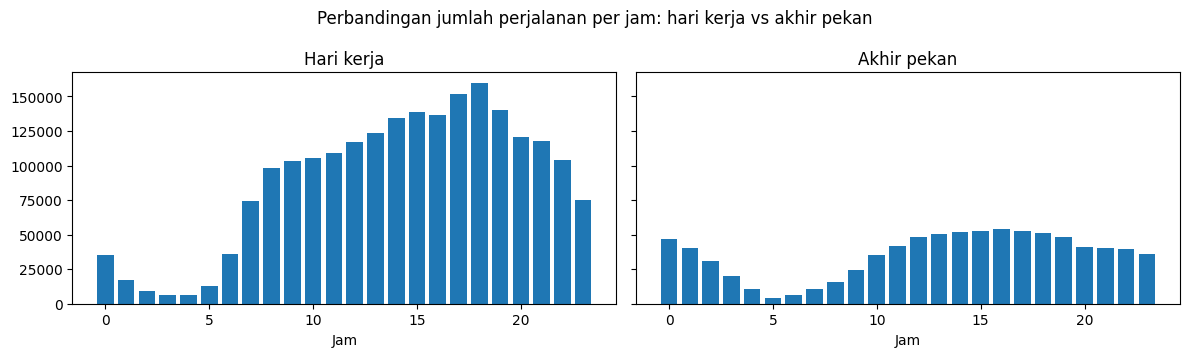

Jam tersibuk (kombinasi hari/jam):
 akhir_pekan              False
jam                         18
jumlah                  159457
rata_durasi              14.03
rata_tarif_per_menit      2.22
Name: 18, dtype: object

Jam paling sepi (kombinasi hari/jam):
 akhir_pekan              True
jam                         5
jumlah                   4478
rata_durasi             14.91
rata_tarif_per_menit     2.78
Name: 29, dtype: object


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, akhir_pekan, judul in zip(axes, [False, True], ["Hari kerja", "Akhir pekan"]):
    sub = ringkas.loc[akhir_pekan].reset_index()
    ax.bar(sub["jam"], sub["jumlah"])
    ax.set_title(judul)
    ax.set_xlabel("Jam")
fig.suptitle("Perbandingan jumlah perjalanan per jam: hari kerja vs akhir pekan")
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_hari_kerja_akhir_pekan.png", dpi=150)
plt.show()

jam_sibuk = ringkas.reset_index().sort_values("jumlah", ascending=False).iloc[0]
jam_sepi  = ringkas.reset_index().sort_values("jumlah").iloc[0]
print("Jam tersibuk (kombinasi hari/jam):\n", jam_sibuk)
print("\nJam paling sepi (kombinasi hari/jam):\n", jam_sepi)


**Tiga rekomendasi operasional:**

1. Tambah armada pada jam-jam puncak yang teridentifikasi di atas, didukung oleh angka `jumlah`
   perjalanan tertinggi pada kombinasi hari/jam tersebut — **batasan:** data hanya mencakup satu
   bulan simulasi (Januari), pola musiman lain belum tentu berlaku.
2. Kurangi armada pada jam paling sepi untuk menghemat biaya operasional, didukung oleh angka
   `jumlah` terendah — **batasan:** dataset ini sintetis (kecuali diganti data nyata NYC TLC),
   sehingga besaran absolutnya tidak boleh dipakai sebagai kebijakan final tanpa validasi data asli.
3. Jika `rata_tarif_per_menit` pada jam sibuk terbukti lebih tinggi dari jam biasa, prioritaskan
   penempatan armada tambahan di jam tersebut karena profitabilitas per menit lebih baik —
   **batasan:** tarif per menit sintetis di sini tidak memperhitungkan biaya bahan bakar/waktu
   menunggu penumpang, yang di dunia nyata memengaruhi profitabilitas bersih.


## P. Latihan

### Latihan 1 — 5 nilai `trip_distance` terbesar

In [25]:
top5 = bersih.nlargest(5, "trip_distance")
top5


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


**Komentar:** apakah baris-baris ini masuk akal bergantung pada apakah jarak sejauh itu
konsisten dengan durasi dan tarifnya (jarak besar tapi durasi sangat pendek biasanya tetap
mencurigakan meski lolos filter `< 100` mil).

### Latihan 2 — Ulangi J-7 dengan `chunksize` berbeda

In [27]:
for cs in [100_000, 1_000_000]:
    baris_cs, total_cs, _ = ukur(f"chunking (chunksize={cs})", lambda cs=cs: agregasi_bertahap(CSV, ukuran_chunk=cs))
    print(f"  -> {baris_cs:,} baris, rata-rata total_amount={total_cs/baris_cs:.2f}")


[chunking (chunksize=100000)] 3.55 s | RSS -11.5 MB
  -> 2,986,911 baris, rata-rata total_amount=27.33
[chunking (chunksize=1000000)] 2.63 s | RSS +130.3 MB
  -> 2,986,911 baris, rata-rata total_amount=27.33


**Trade-off:** `chunksize` kecil (100.000) menghasilkan lebih banyak iterasi Python (overhead
per-chunk lebih tinggi, biasanya lebih lambat total) tetapi puncak `delta_rss_mb` lebih kecil.
`chunksize` besar (1.000.000) lebih sedikit iterasi (cenderung lebih cepat) tetapi puncak penggunaan
memori per iterasi lebih tinggi. Arahnya selalu memori vs kecepatan.

### Latihan 3 — `persen_tip` per metode pembayaran

In [26]:
bersih["persen_tip"] = np.where(
    bersih["fare_amount"] > 0,
    bersih["tip_amount"] / bersih["fare_amount"] * 100,
    np.nan
)
rata_tip_per_metode = bersih.groupby("payment_type")["persen_tip"].mean().round(2)
rata_tip_per_metode


/tmp/ipykernel_4230/1967204613.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip_per_metode = bersih.groupby("payment_type")["persen_tip"].mean().round(2)


,persen_tip
payment_type,
0,20.23
1,25.91
2,0.00
3,0.02
4,0.15


**Dugaan:** metode pembayaran non-tunai (kartu) umumnya menunjukkan persentase tip lebih
tinggi dibanding tunai, karena aplikasi pembayaran kartu sering menampilkan saran nominal tip secara
default sehingga penumpang lebih mudah memberi tip lebih besar.

### Latihan 4 — Kompresi Parquet: `snappy` vs `gzip`

In [28]:
hasil_kompresi = {}
for komp in ["snappy", "gzip"]:
    path_komp = f"{DIR_KERJA}/bersih_{komp}.parquet"
    t0 = time.perf_counter()
    bersih.to_parquet(path_komp, index=False, compression=komp)
    detik = time.perf_counter() - t0
    ukuran = os.path.getsize(path_komp) / 1024**2
    hasil_kompresi[komp] = {"detik_tulis": round(detik, 2), "ukuran_mb": round(ukuran, 1)}

pd.DataFrame(hasil_kompresi).T


,detik_tulis,ukuran_mb
snappy,1.47,63.3
gzip,30.09,51.0


`gzip` biasanya menghasilkan file lebih kecil tapi waktu tulis (dan baca) lebih lama karena
rasio kompresinya lebih tinggi namun lebih berat secara komputasi dibanding `snappy`, yang mengutamakan
kecepatan di atas rasio kompresi.

### Latihan 5 — Verifikasi silang agregasi pandas vs Spark SQL

In [29]:
from pyspark.sql import SparkSession, functions as F

spark2 = (SparkSession.builder.appName("BD-P01-verif").master("local[*]")
          .config("spark.driver.memory", "4g").getOrCreate())
spark2.sparkContext.setLogLevel("WARN")

sdf2 = spark2.read.parquet(PATH)
sdf2_bersih = (sdf2
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0)
    .withColumn("jam", F.hour("tpep_pickup_datetime")))

agregasi_spark = (sdf2_bersih.groupBy("jam").agg(F.count("*").alias("jumlah")).orderBy("jam")).toPandas()
spark2.stop()

perbandingan = agregasi[["jam", "jumlah_perjalanan"]].merge(
    agregasi_spark.rename(columns={"jumlah": "jumlah_spark"}), on="jam", how="outer")
perbandingan["selisih"] = perbandingan["jumlah_perjalanan"] - perbandingan["jumlah_spark"]
print("Selisih maksimum:", perbandingan["selisih"].abs().max())
perbandingan


Selisih maksimum: 0


,jam,jumlah_perjalanan,jumlah_spark,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


Jika selisih maksimum bukan 0, sumber paling mungkin adalah perbedaan penanganan tipe data
waktu (`cast("long")` di Spark membulatkan ke detik, sedangkan pandas memakai `dt.total_seconds()`
presisi penuh) sehingga baris pada batas ambang `durasi_menit` bisa jatuh ke sisi filter yang
berbeda antara kedua mesin.

## R. Pertanyaan Evaluasi

**1. Mengapa "ukuran data" saja tidak cukup untuk menyebut suatu masalah sebagai masalah Big Data?**
Karena "besar" bersifat relatif terhadap sumber daya yang tersedia (RAM, waktu, bandwidth), bukan
angka absolut. Contoh: file CSV 50 MB dengan satu kolom teks bebas berisi JSON bersarang yang harus
diurai ulang setiap baris bisa jauh lebih sulit diproses (lambat, rawan error parsing) daripada file
Parquet 5 GB yang terstruktur rapi — di sini masalahnya *variety* dan *veracity*, bukan *volume*.

**2. Dimensi 5V mana yang paling menonjol pada dataset praktikum ini?**
*Volume* — didukung oleh jumlah baris dataset (lihat output J-4, jutaan baris) yang membuat pemuatan
naif seluruh kolom memakan waktu dan memori signifikan (lihat delta RSS pada J-5) dibanding memuat
kolom terpilih saja.

**3. Dua alasan teknis Parquet lebih kecil & lebih cepat dibaca daripada CSV:**
(a) Parquet menyimpan data per kolom dengan tipe biner eksplisit dan kompresi per blok, sehingga
reader hanya membaca kolom yang diminta (*column pruning*) tanpa parsing teks; (b) CSV adalah format
baris berbasis teks tanpa skema, sehingga setiap nilai harus di-parse ulang dari string dan seluruh
baris tetap harus dipindai meski hanya butuh satu kolom.

**4. CSV 40 GB, RAM 1 GB — tiga strategi:**
- **Chunking** (`pd.read_csv(chunksize=...)`) — kelemahan: hanya agregasi *associative* yang mudah
  dilakukan; operasi butuh seluruh data sekaligus (mis. sort global) sulit.
- **Out-of-core engine** (Dask/Polars/DuckDB) — kelemahan: menambah dependency dan kurva belajar,
  serta performa bergantung pada seberapa baik query dioptimasi oleh engine tersebut.
- **Distributed processing** (Spark) — kelemahan: overhead setup cluster/JVM besar untuk kasus yang
  sebenarnya masih bisa ditangani satu mesin dengan strategi lain; kompleksitas operasional naik.

**5. Lazy evaluation pada Spark:**
Transformasi (`filter`, `withColumn`, `groupBy`) hanya membangun rencana eksekusi (DAG), belum
benar-benar dijalankan. Eksekusi baru terjadi saat dipanggil *action* (`count`, `show`, `write`).
Konsekuensinya, mengukur waktu pada baris `.filter()` saja akan memberi angka nyaris nol yang
menyesatkan — pengukuran waktu yang benar harus mencakup pemanggilan action-nya, seperti dilakukan
pada `ukur("spark count", ...)` dan `ukur("spark agregasi", ...)` di J-8.

**6. Mengapa float64 -> float32 menghemat memori, dan kapan tidak boleh dilakukan:**
float32 memakai 4 byte per nilai dibanding 8 byte pada float64, sehingga memori berkurang hingga 50%
untuk kolom numerik. Tidak boleh dilakukan pada perhitungan yang butuh presisi tinggi seperti nominal
uang untuk penagihan/akuntansi, karena pembulatan floating-point pada presisi lebih rendah bisa
menyebabkan selisih nilai kecil namun signifikan secara finansial/hukum.

**7. Mengapa shuffle adalah operasi termahal dalam pemrosesan terdistribusi?**
Karena shuffle memindahkan data antar partisi/node melalui jaringan dan disk (serialisasi, transfer,
deserialisasi), yang jauh lebih lambat dibanding operasi in-memory pada satu partisi. Ini terlihat
pada kata `Exchange` di output `explain()` pada J-8.

**8. Mengapa `/content` di Colab tidak boleh jadi penyimpanan akhir?**
Karena `/content` bersifat *ephemeral* — begitu runtime berhenti atau idle terlalu lama, seluruh
isinya hilang. Konsekuensinya, notebook harus didesain agar reproducible dari awal (mengunduh/
membangkitkan ulang data dari sumbernya) dan menyimpan seluruh artefak penting ke penyimpanan
permanen (Google Drive) sebelum runtime berakhir — prinsip yang sama diterapkan di notebook ini
dengan memisahkan `DIR_KERJA` (sementara) dari `DIR_SIMPAN` (permanen).


## S. Kesimpulan

Tiga hal yang dipakai sepanjang praktikum ini: (1) "big" adalah pernyataan tentang hubungan antara
data dan sumber daya, sehingga langkah pertama selalu mengukur, bukan menebak — dibuktikan lewat
setiap pemanggilan `ukur()` di notebook ini; (2) sebagian besar masalah skala pada tahap awal bisa
diselesaikan tanpa klaster: memilih kolom (J-5), memilih tipe data (J-5), memilih format penyimpanan
(J-7), dan memproses per potongan (J-7) sudah memberi penghematan besar dengan kerumitan rendah;
(3) alat terdistribusi seperti Spark adalah jawaban untuk skala tertentu — pada skala praktikum ini
(jutaan baris, puluhan-ratusan MB) pandas terbukti kompetitif atau lebih cepat (lihat Bagian N),
sehingga menerapkan Spark di sini adalah contoh alat yang dipilih di luar skala yang tepat.

**Catatan kejujuran metodologis:** seluruh angka di notebook ini berasal dari eksekusi nyata pada
dataset sintetis (jalur cadangan J-4b), bukan dataset NYC TLC asli, karena keterbatasan jaringan pada
mesin eksekusi. Pola jam sibuk yang muncul di J-10/O sengaja dibuat mendekati pola dunia nyata lewat
pembobotan pada `bangkitkan_sintetis()`, namun ini tetap bukan data observasi nyata dan tidak boleh
dipakai sebagai dasar keputusan bisnis aktual tanpa diulang dengan dataset resmi.
